# Importing Libraries

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

<Figure size 1000x600 with 0 Axes>

# Read cleaned dataset

In [3]:
df = pd.read_excel('EDA_Cleaned_Dataset.xlsx')
df.head()

,Date,Product,Quantity,UnitPrice,PaymentMethod,OrderStatus,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,2023-01-04,Monitor,5,570.62,Debit Card,Shipped,7,SAVE10,Instagram,2853.10
1,2024-08-23,Phone,2,151.35,Online,Shipped,3,SAVE10,Referral,302.70
2,2024-02-27,Tablet,5,550.68,Credit Card,Cancelled,8,FREESHIP,Email,2753.40
3,2023-10-15,Chair,1,273.19,Debit Card,Returned,5,SAVE10,Facebook,273.19
4,2025-05-08,Printer,4,626.01,Online,Delivered,8,SAVE10,Email,2504.04


In [4]:
df.tail()

,Date,Product,Quantity,UnitPrice,PaymentMethod,OrderStatus,ItemsInCart,CouponCode,ReferralSource,TotalPrice
1195,2024-06-20,Desk,1,107.04,Credit Card,Cancelled,6,FREESHIP,Google,107.04
1196,2024-03-04,Monitor,2,662.53,Online,Cancelled,5,No Coupon,Facebook,1325.06
1197,2023-07-13,Tablet,2,436.84,Online,Delivered,2,FREESHIP,Instagram,873.68
1198,2024-08-22,Chair,4,262.52,Debit Card,Cancelled,4,WINTER15,Instagram,1050.08
1199,2023-06-11,Tablet,4,560.58,Gift Card,Returned,6,SAVE10,Referral,2242.32


In [5]:
df.shape

(1200, 10)

In [6]:
print ("Data information:")
import io
buf = io.StringIO()
df.info(buf=buf)
s = buf.getvalue()
lines = [line.split() for line in s.splitlines()[3:-2]]
info = pd.DataFrame(lines)
info.columns = info.iloc[0]
info

Data information:


,#,Column,Non-Null,Count,Dtype
0,#,Column,Non-Null,Count,Dtype
1,---,------,--------------,-----,None
2,0,Date,1200,non-null,datetime64[ns]
3,1,Product,1200,non-null,object
4,2,Quantity,1200,non-null,int64
5,3,UnitPrice,1200,non-null,float64
6,4,PaymentMethod,1200,non-null,object
7,5,OrderStatus,1200,non-null,object
8,6,ItemsInCart,1200,non-null,int64
9,7,CouponCode,1200,non-null,object


In [7]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


# Start visualization 

## Mono

##### Histogram

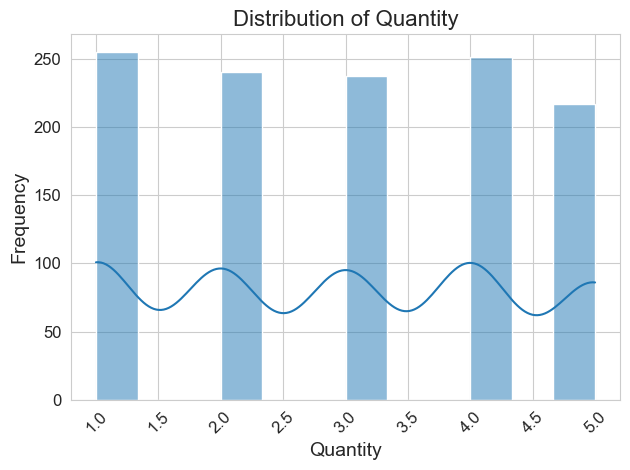

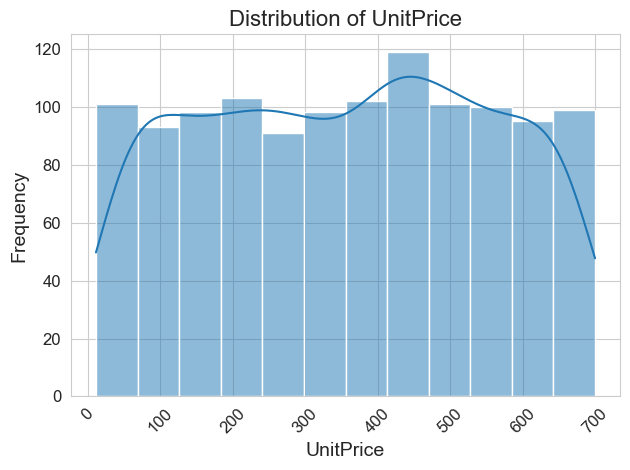

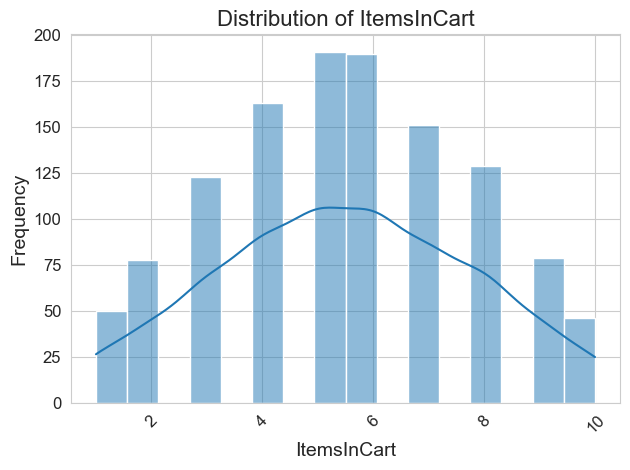

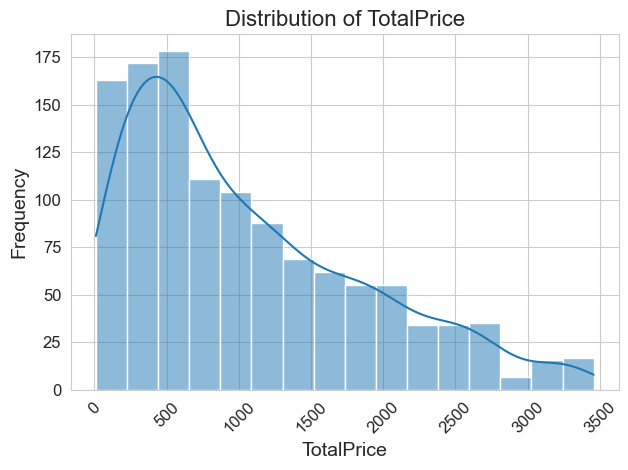

In [8]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
  sns.histplot(df[col], kde=True)
  plt.title(f'Distribution of {col}', fontsize=16)
  plt.xlabel(col, fontsize=14)
  plt.ylabel('Frequency', fontsize=14)
  plt.xticks(rotation=45, fontsize=12)
  plt.yticks(fontsize=12)
  plt.tight_layout()
  plt.show()

#### BOX Plot

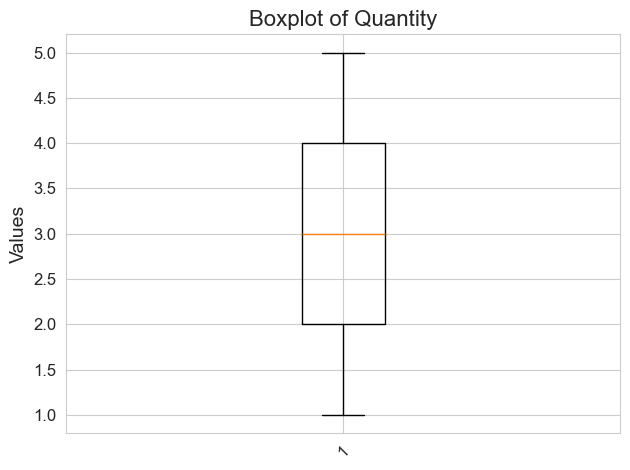

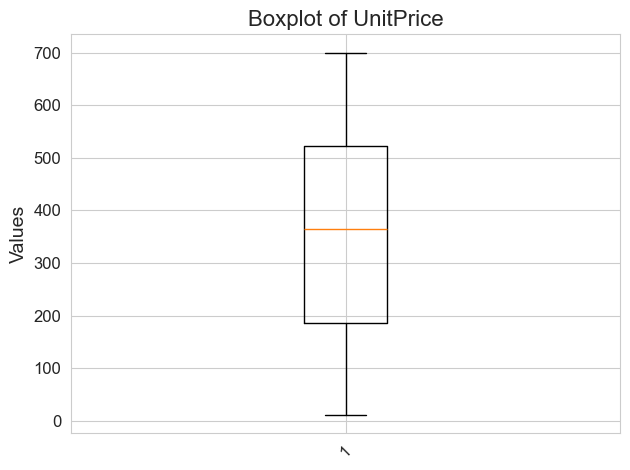

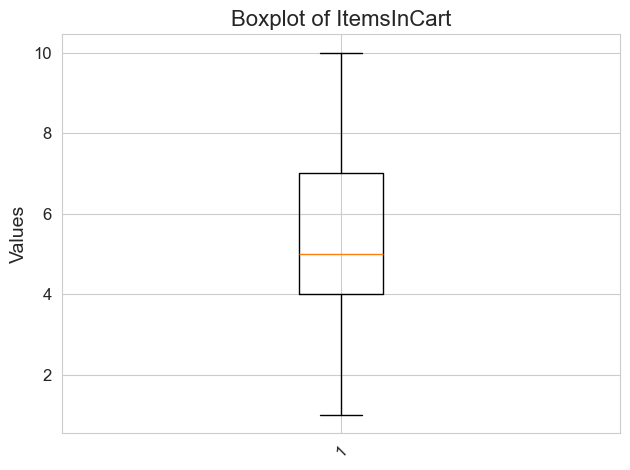

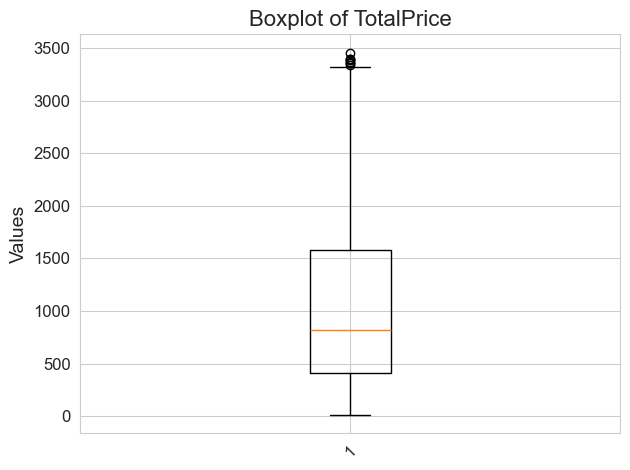

In [9]:
for col in numeric_cols:
  plt.boxplot(df[col])
  plt.title(f'Boxplot of {col}', fontsize=16)
  plt.ylabel('Values', fontsize=14)
  plt.xticks(rotation=45, fontsize=12)
  plt.yticks(fontsize=12)
  plt.tight_layout()
  plt.show()

## Di

#### Boxplot for each category with a unit price 

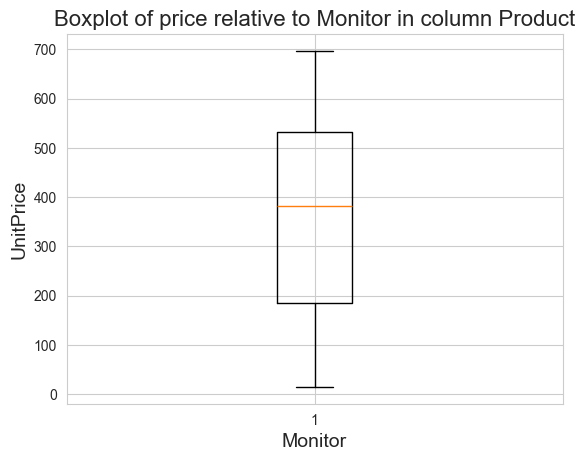

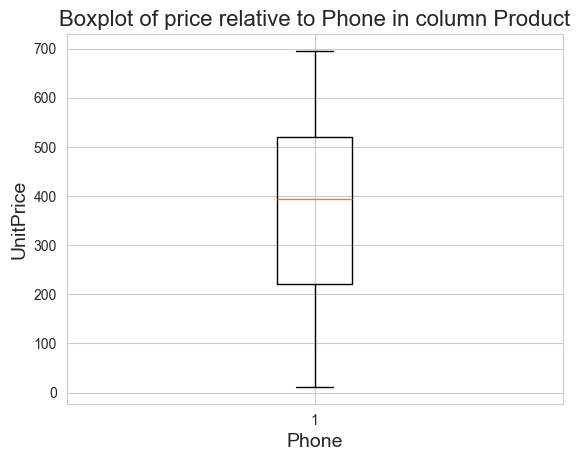

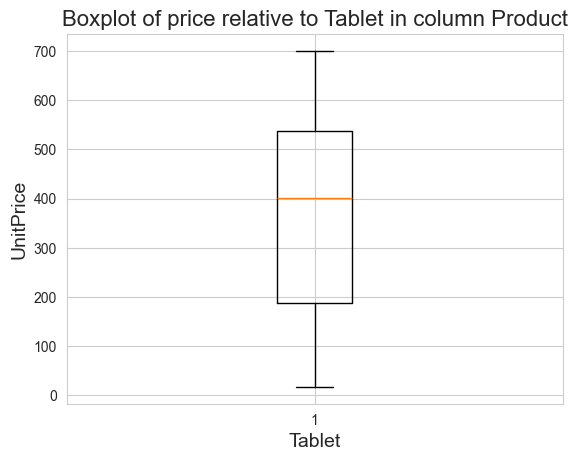

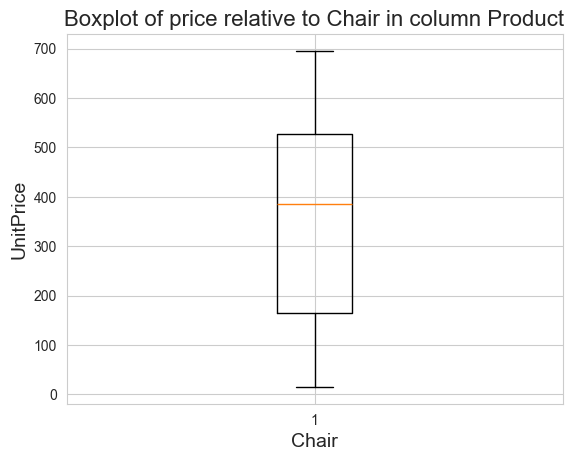

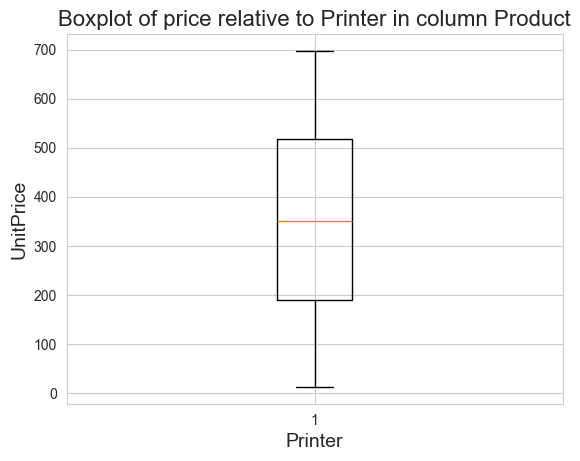

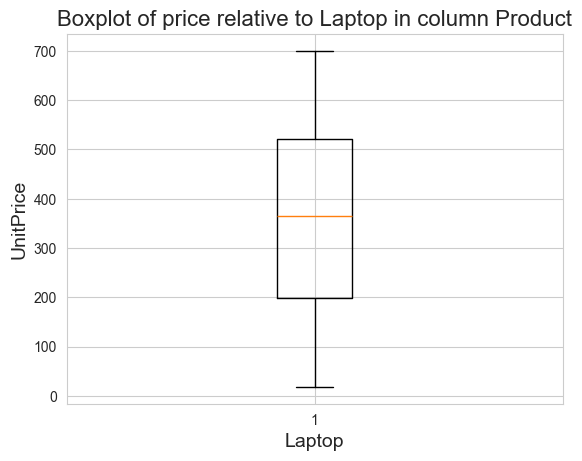

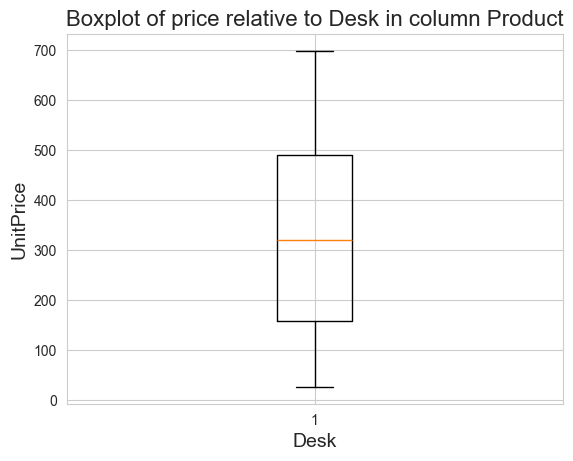

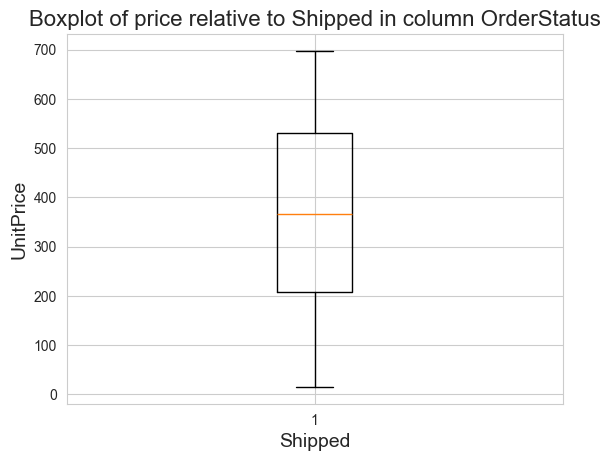

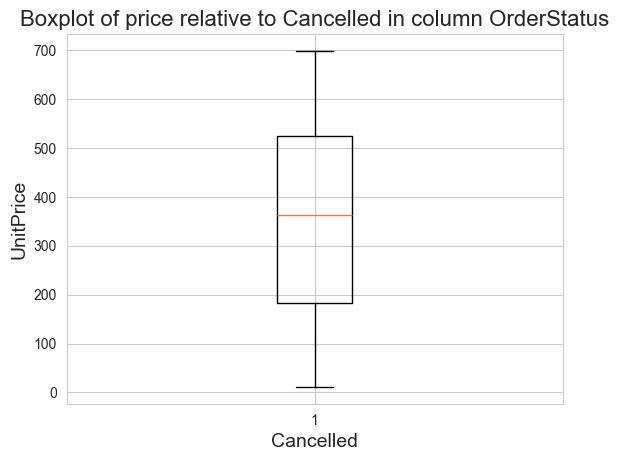

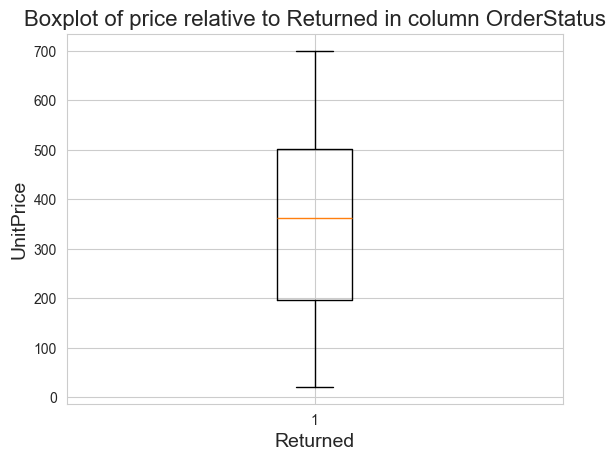

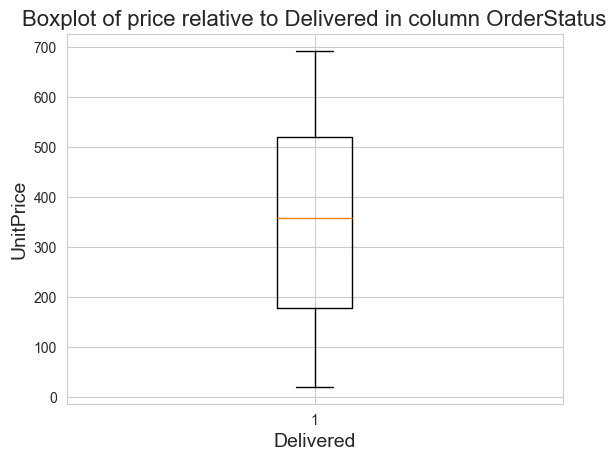

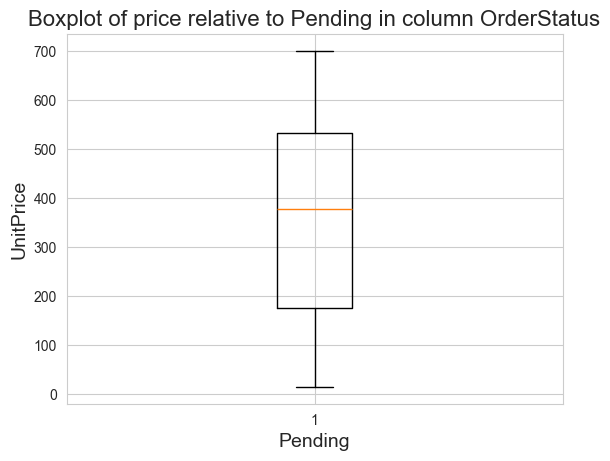

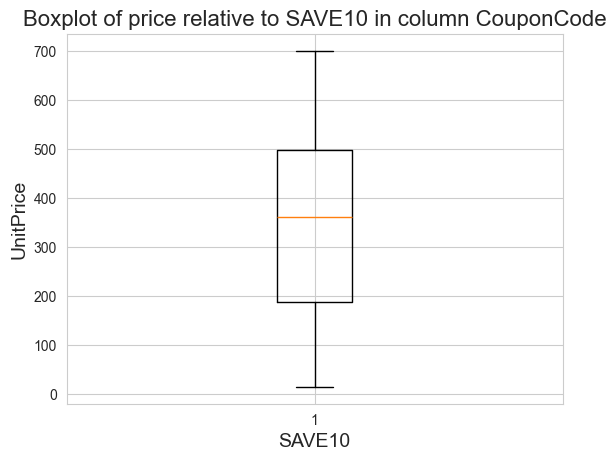

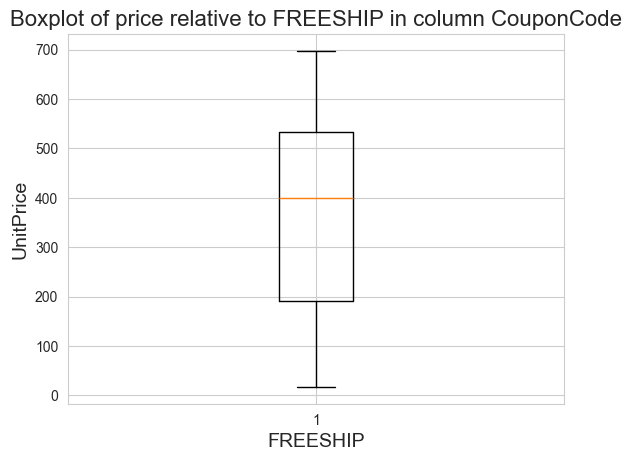

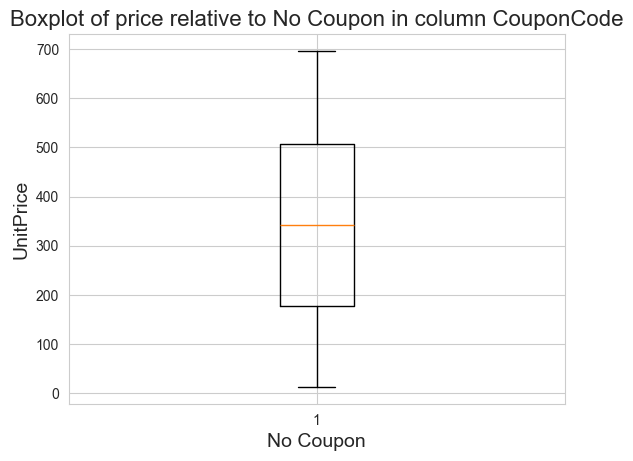

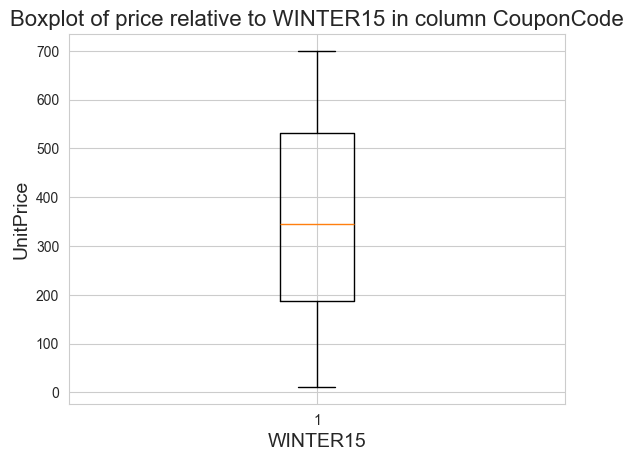

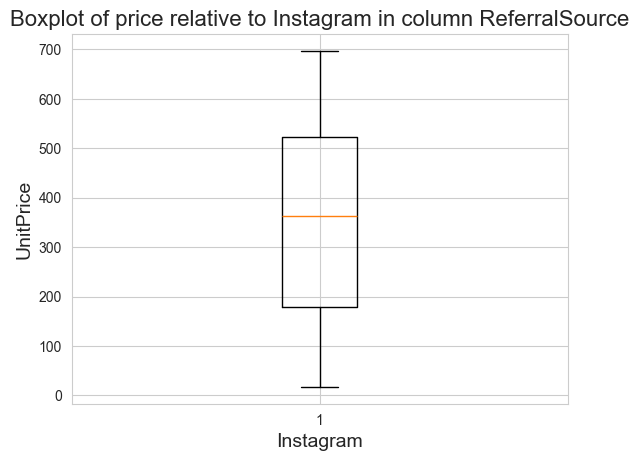

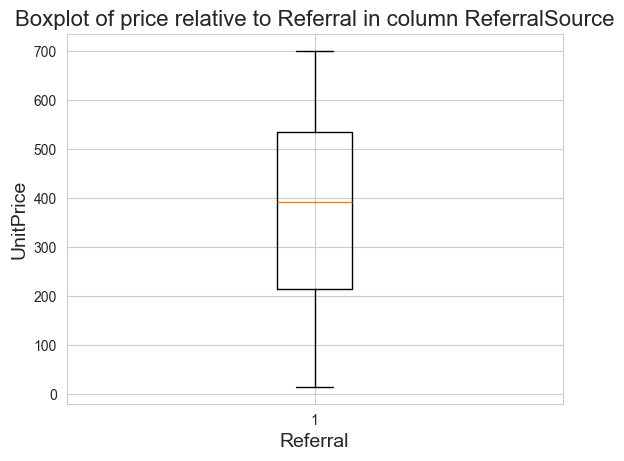

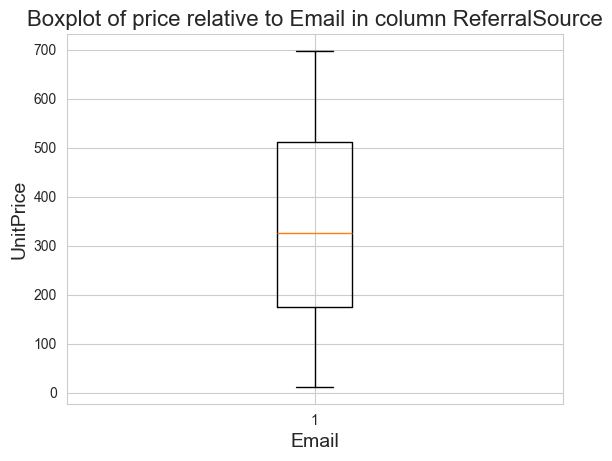

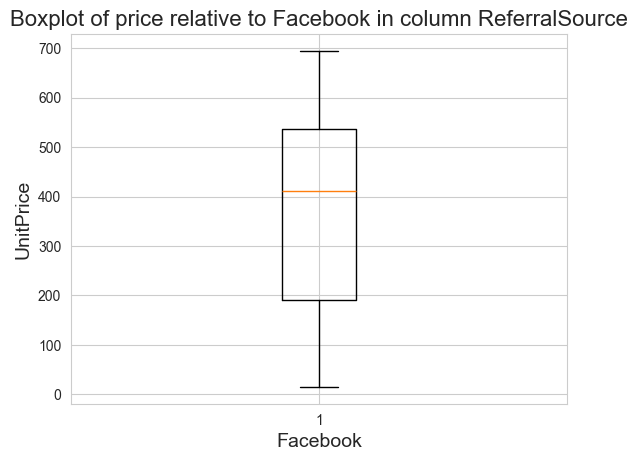

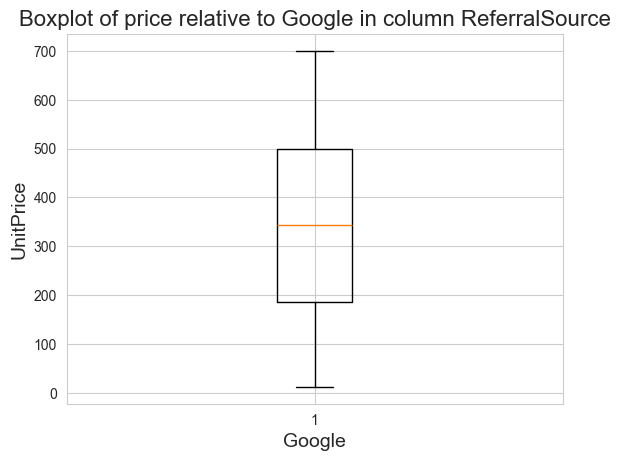

In [10]:
object_cols = df.select_dtypes(include=['object']).columns
for col in object_cols:
  if col == 'PaymentMethod':
    continue
  for item in df[col].unique():
    plt.title(f'Boxplot of price relative to {item} in column {col}', fontsize=16)
    plt.xlabel(item, fontsize=14)
    plt.ylabel('UnitPrice', fontsize=14)
    plt.boxplot(df[df[col] == item]['UnitPrice'])
    plt.show()

#### Boxplot for each category with the total price

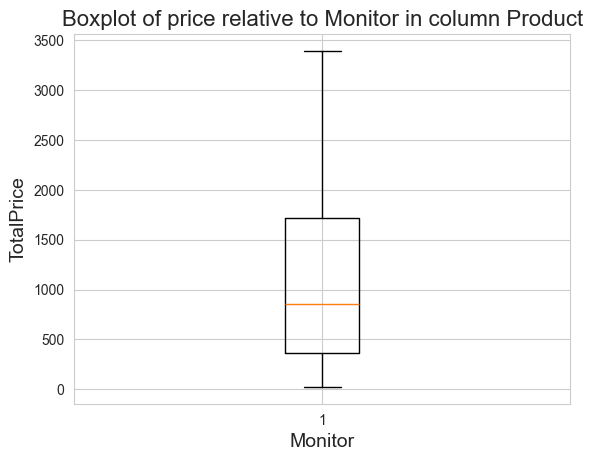

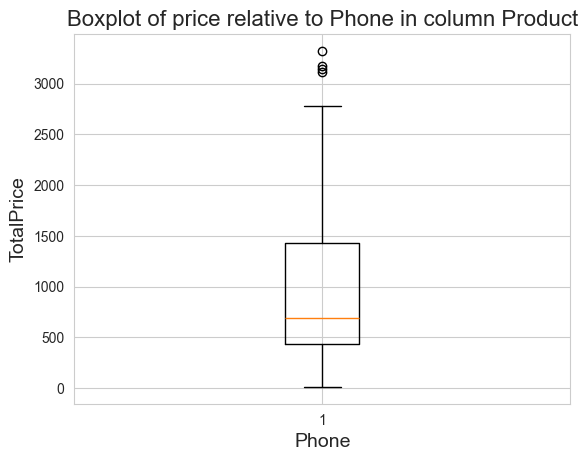

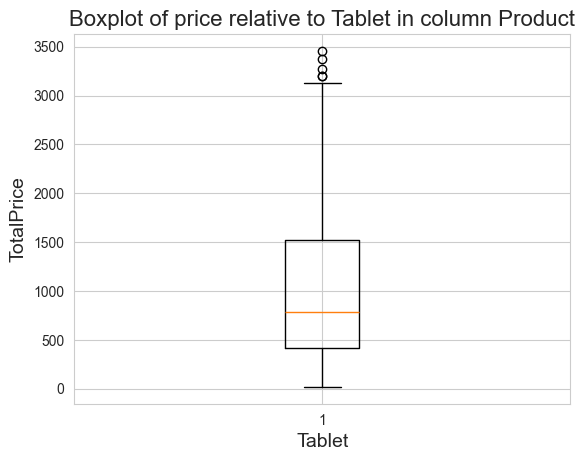

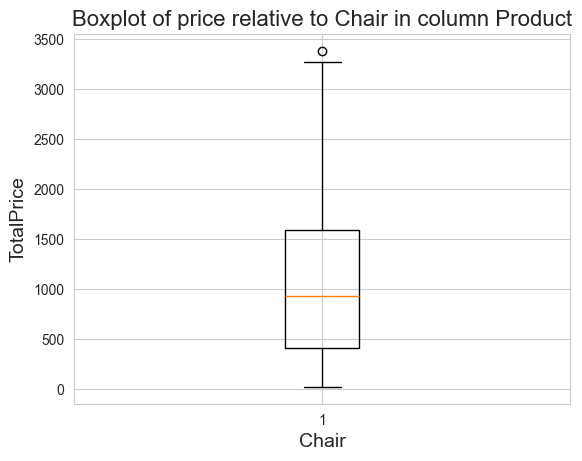

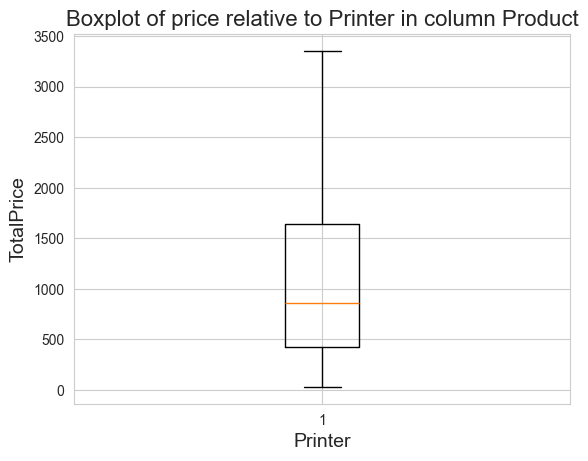

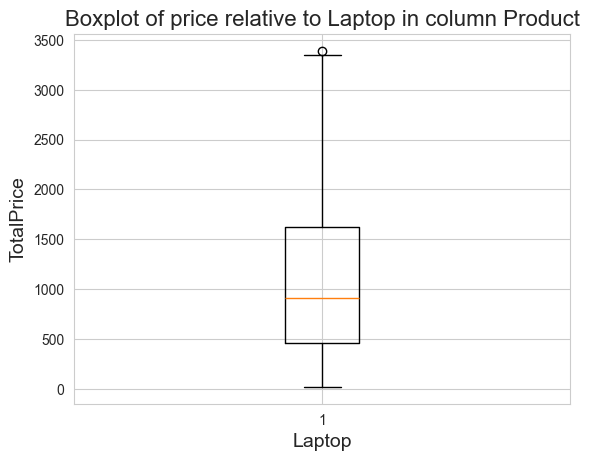

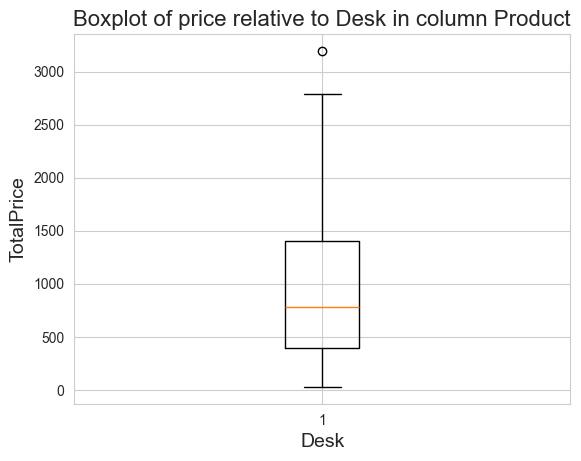

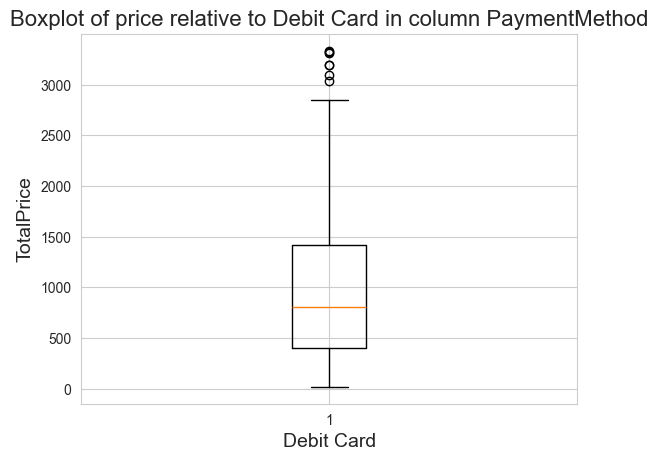

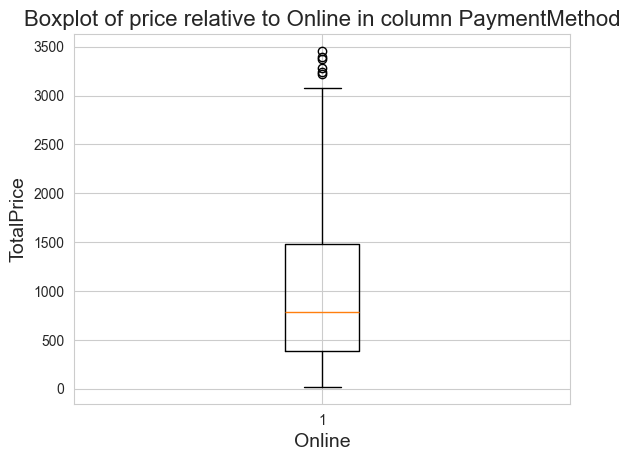

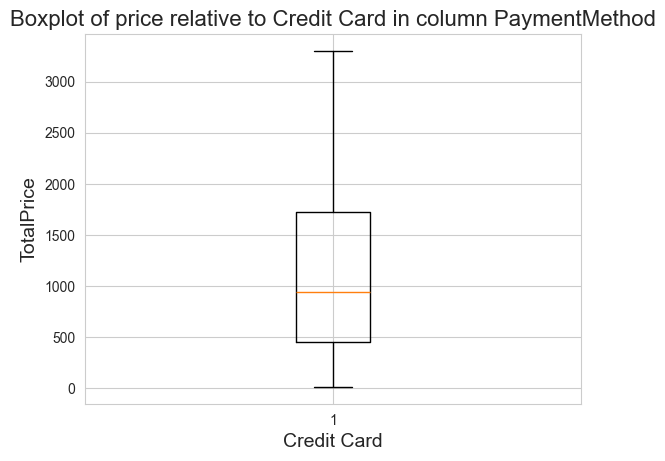

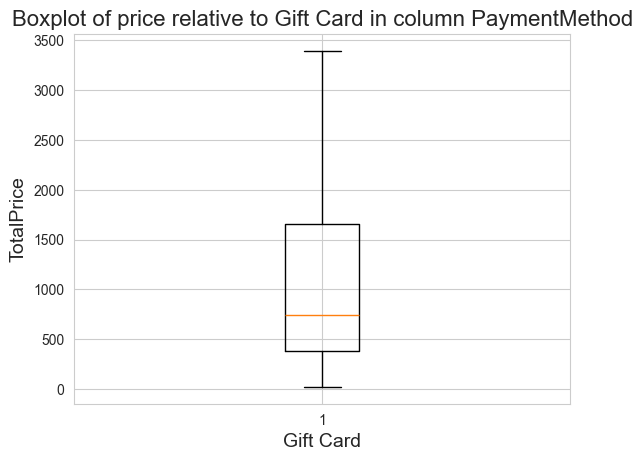

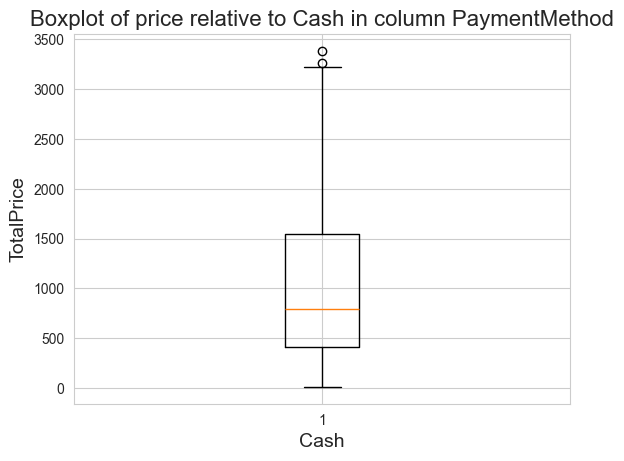

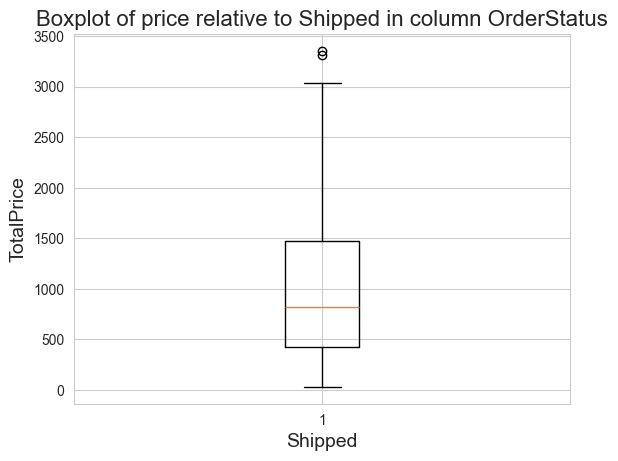

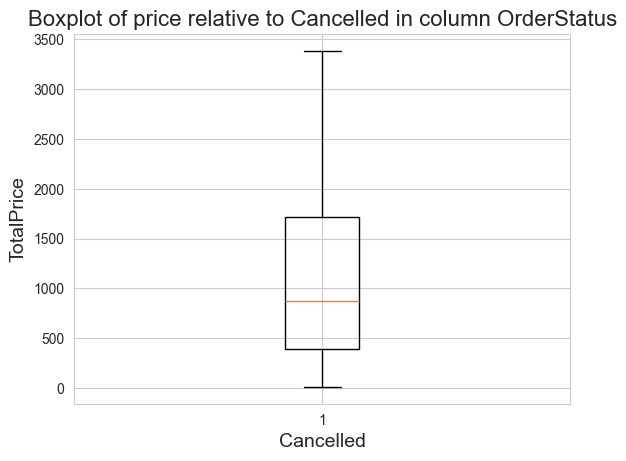

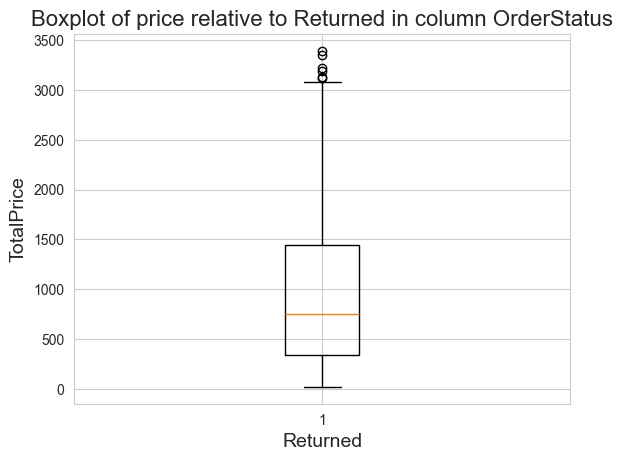

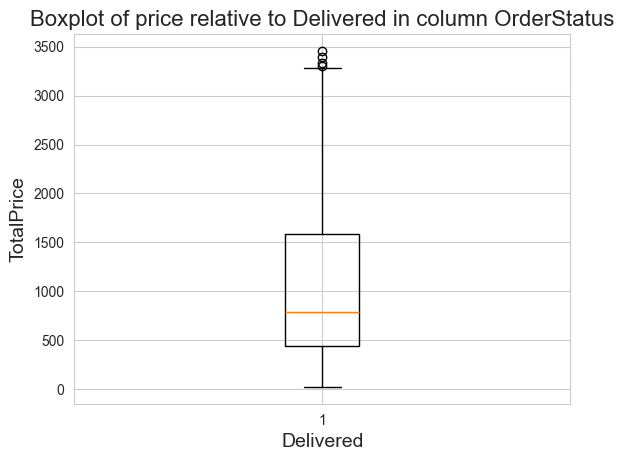

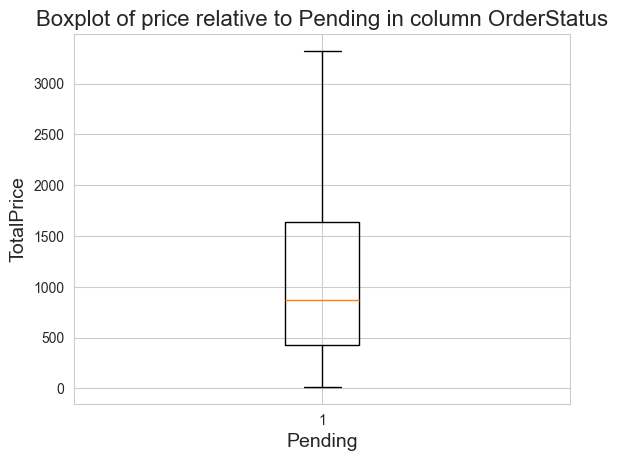

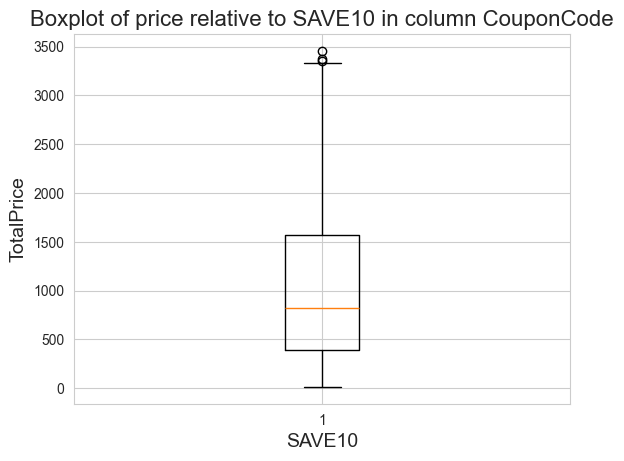

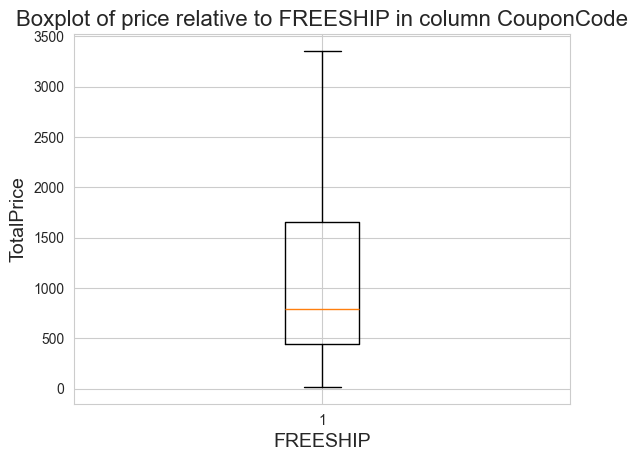

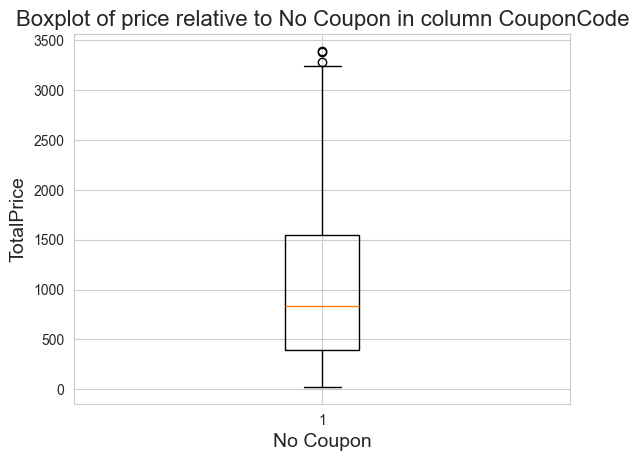

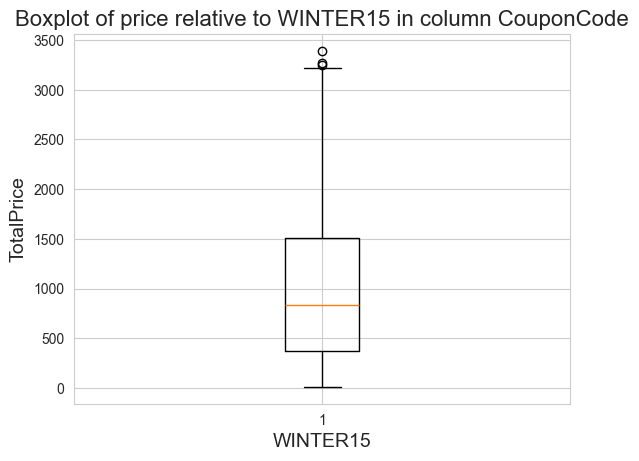

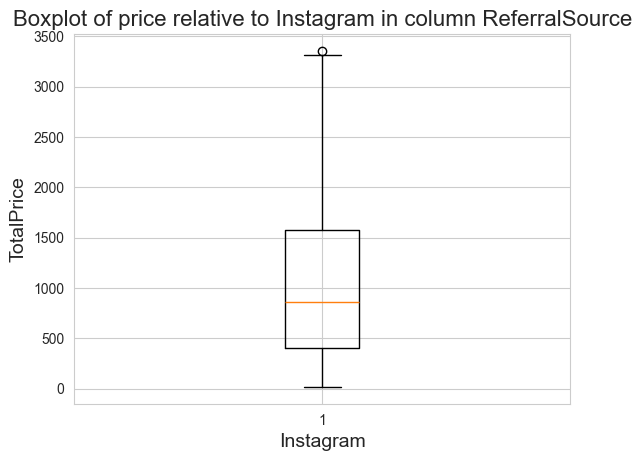

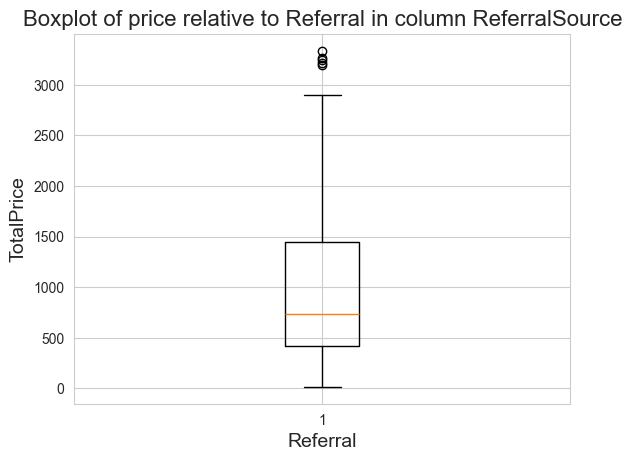

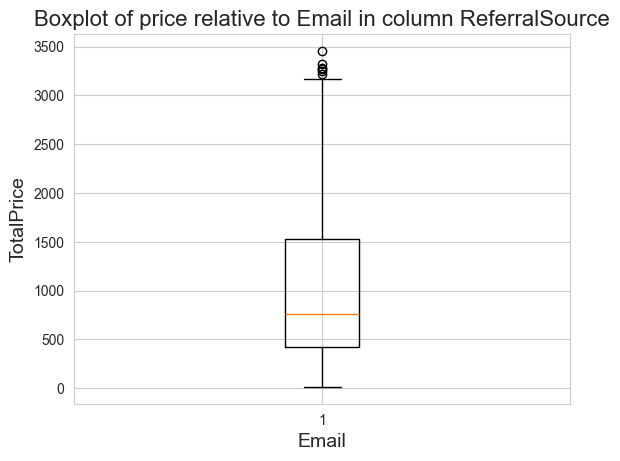

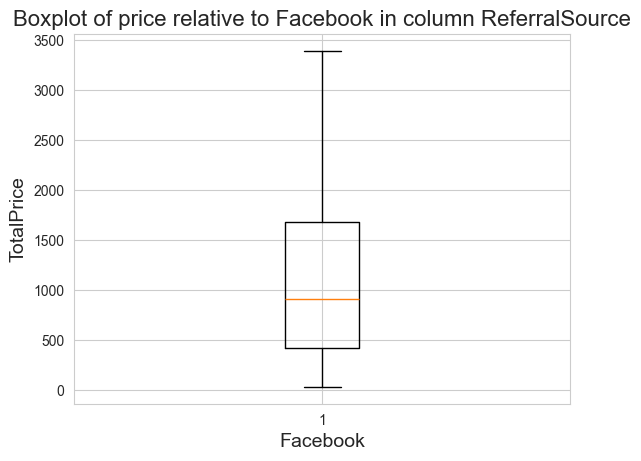

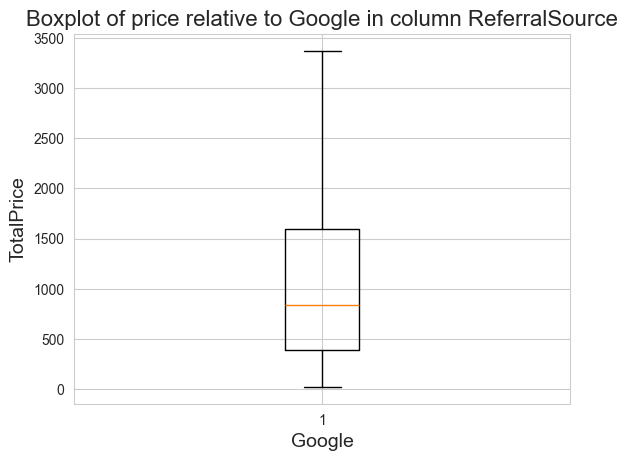

In [11]:
object_cols = df.select_dtypes(include=['object']).columns
for col in object_cols:
  for item in df[col].unique():
    plt.title(f'Boxplot of price relative to {item} in column {col}', fontsize=16)
    plt.xlabel(item, fontsize=14)
    plt.ylabel('TotalPrice', fontsize=14, rotation=90)
    plt.boxplot(df[df[col] == item]['TotalPrice'])
    plt.show()

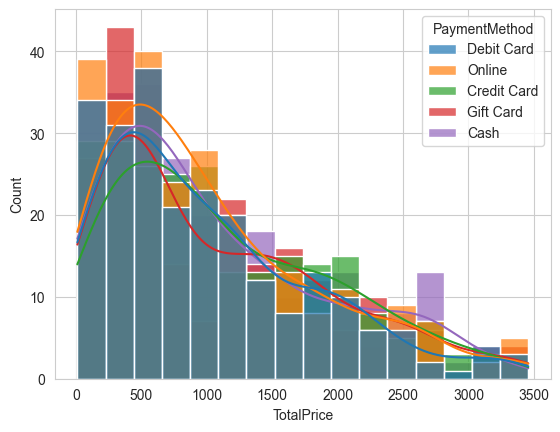

In [12]:
sns.histplot(data=df, x='TotalPrice', hue='PaymentMethod', kde=True, alpha=0.7)
plt.show()